# Autogen API Overview

- This notebook shows the working of autogen API and all its individual components and its explanations.

In [12]:
import asyncio
import os
import PIL.Image
import IPython.display
import autogen_core
import autogen_agentchat.teams as teams
import autogen_ext.models.openai as openai  # For OpenAIChatCompletionClient
import autogen_agentchat.agents as agent    # For AssistantAgent
import autogen_agentchat.messages as msg     # For Message and Event types
import autogen_agentchat.base as base        # For TaskResult
from autogen_core.models import UserMessage


The **cell below** instantiates the OpenAI chat completion client, binding it to a specific model and authenticating with the provided API key.

In [ ]:
openai_model_client = openai.OpenAIChatCompletionClient(
    model="gpt-4o-2024-08-06",
    api_key="YOUR_OPENAI_API_KEY", 
)

This **cell below** sends a user message to the OpenAI model client and prints the model’s response.

In [11]:
result = await openai_model_client.create([UserMessage(content="What is the capital of France?", source="user")])
print(result)

finish_reason='stop' content='The capital of France is Paris.' usage=RequestUsage(prompt_tokens=15, completion_tokens=7) cached=False logprobs=None thought=None


## Messages
There are primarily 2 types of messages in autogen:
- Agent-Agent Messages
- Agent's Internal Events

### The Below cell shows the working of Agent to Agent communication

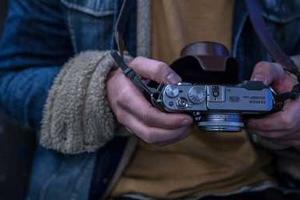


--- Message from User ---
['Look at this camera feed and discuss it.', <autogen_core._image.Image object at 0x76d4d23c5b80>]

--- Message from Vision_Specialist ---
The image shows a person holding a camera. The camera appears to be a vintage or retro-style model with a leather strap. The person is wearing a denim jacket with a shearling lining, and a tan shirt is visible underneath. The focus is on the camera rather than the individual holding it, indicating an interest in photography or the camera itself. The setting suggests a casual or candid moment, possibly capturing a scene or preparing to take a photo. The lighting is somewhat low, implying it might be evening or an indoor environment.

--- Message from Reviewer ---
The image highlights a person holding a retro-style camera, suggesting a passion for photography or an interest in vintage cameras. The denim jacket with shearling lining and the casual attire create a relaxed, candid vibe. This setting could be ideal for capturing

In [24]:
# 1. Setup the Model Client (using existing openai_model_client from previous step)

# 2. Define Agent A: The Vision Specialist
vision_agent = autogen_agentchat.agents.AssistantAgent(
    name="Vision_Specialist",
    model_client=openai_model_client,
    system_message="Describe the image provided in detail."
)

# 3. Define Agent B: The Reviewer
reviewer_agent = autogen_agentchat.agents.AssistantAgent(
    name="Reviewer",
    model_client=openai_model_client,
    system_message="Based on the description provided, suggest one creative use for this item."
)

# 4. Create the Team (This enables true Agent-to-Agent communication)
agent_team = autogen_agentchat.teams.RoundRobinGroupChat(
    [vision_agent, reviewer_agent],
    max_turns=2
)

# 5. Prepare the MultiModalMessage from your local file
pil_image = PIL.Image.open("camera.png")
img = autogen_core.Image(pil_image)
IPython.display.display(pil_image)

input_message = autogen_agentchat.messages.MultiModalMessage(
    content=["Look at this camera feed and discuss it.", img],
    source="User"
)

# 6. Run the Team
# The team will pass the MultiModalMessage from the User to Agent A, 
# then Agent A's response to Agent B automatically.
async for message in agent_team.run_stream(task=input_message):
    # TaskResult objects don't have 'source', so we check if 'source' exists
    if hasattr(message, "source"):
        print(f"\n--- Message from {message.source} ---")
        print(message.content)
    else:
        # This handles the final TaskResult object
        print("\n--- Task Complete ---")
        # Optional: print(message.stop_reason)

### Agent's Internal Events
- In the below example, the agent does not show reasoning because the question is a simple factual lookup, and the model directly produces the answer without generating visible step-by-step reasoning.

In [14]:
async def main():
    # 1. Setup the client using the 'openai' alias

    # 2. Setup the agent using the 'agent' alias
    # model_client_stream=True is required to see the internal 'Thinking' events
    solo_agent = agent.AssistantAgent(
        name="Solo_Assistant",
        model_client=openai_model_client,
        system_message="You are a helpful assistant.",
        model_client_stream=True 
    )

    print("--- Execution Started ---\n")

    # 3. Process the stream using the 'msg' and 'base' aliases
    async for event in solo_agent.run_stream(task="What is the capital of France?"):
        
        # Internal "Live" Streaming (Individual tokens as they arrive)
        if isinstance(event, msg.ModelClientStreamingChunkEvent):
            if event.content:
                print(event.content, end="", flush=True)

        # Final Messages (Completed response blocks)
        # We check specific types to avoid the generic ChatMessage TypeError
        elif isinstance(event, (msg.TextMessage, msg.MultiModalMessage, msg.StopMessage)):
            # Filter out the 'user' prompt to keep the output clean
            if event.source != "user":
                print(f"\n\n[FINAL MESSAGE from {event.source}]:")
                print(event.content)

        # Final Summary using the 'base' alias
        elif isinstance(event, base.TaskResult):
            print(f"\n\n--- Task Finished | Reason: {event.stop_reason} ---")

# Run the block
await main()

--- Execution Started ---

The capital of France is Paris.

[FINAL MESSAGE from Solo_Assistant]:
The capital of France is Paris.


--- Task Finished | Reason: None ---


## Agents

